# 04 — Classifier 평가

**공정 평가 Step 4/4**: 02 (VP-SGLD) / 03 (TabEBM) 에서 만든 샘플로 classifier 성능 평가.

- CPU only, 수초 내 완료
- 이전 step 결과를 바꾸지 않으므로 **반복 실행 가능**
- VP-SGLD config + TabEBM config 자동 감지
- **N_SYN sweep**: 큰 N 으로 생성한 샘플에서 잘라서 여러 N 비교
- config / classifier / N_SYN 모두 선택 가능

## 0. Setup

## Validation usage policy

**Option B (현재 active)** — `xgboost` 만 external val 로 early stopping:
- `early_stopping_rounds=10`, `eval_set=[(X_val, y_val)]`
- paper PDF Sec 3 의 "val for early stopping" 을 **부분 채택**
- `xgboost` 가 overfit 위험 가장 큼 (default 100 trees), val 활용 효과 가장 큼
- 나머지 (`knn`/`lr`/`rf`/`mlp`/`tabpfn`) 는 val 미사용 (공식 `run_experiment.py` 와 동일)

**Option C (future, 미구현)** — MLP 도 val 활성화:
- sklearn `MLPClassifier` 는 external `eval_set` 미지원 → 직접 training loop 필요
- 구현안 2가지 (fit_classifier 내 주석 참고):
  - C1: concat(tr, val) + `validation_fraction` + `shuffle=False` (fragile)
  - C2: `partial_fit` manual loop + val loss monitor (paper 의도 정확, 복잡)

**Manifest 기록**:
```
"validation_policy": "option_B_xgboost_only"
"xgboost_uses_val_early_stopping": true
"mlp_uses_val_early_stopping": false
```

**전환 시 고려사항**:
- B → C 전환하면 `mlp` 의 bacc 변동 → 이전 run 과 비교 불가
- 전체 실험 재실행 필요 (04 eval 만 재실행이면 2-3분)


In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys, json, time
from pathlib import Path

os.chdir('/home/work/JooKyung/TabEBM')
sys.path.insert(0, 'experiments'); sys.path.insert(0, 'src')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from tabpfn import TabPFNClassifier

pd.set_option('display.width', 220)
pd.set_option('display.precision', 3)

# Classifier builder (기본 인자) — val 사용은 fit_classifier 에서 handle
CLASSIFIER_BUILDERS = {
    'knn':     lambda s: KNeighborsClassifier(n_jobs=-1),
    'lr':      lambda s: LogisticRegression(max_iter=1000, n_jobs=-1, random_state=s),
    'rf':      lambda s: RandomForestClassifier(n_jobs=-1, random_state=s),
    'xgboost': lambda s: xgb.XGBClassifier(n_jobs=-1, eval_metric='logloss',
                                            use_label_encoder=False, random_state=s),
    'mlp':     lambda s: MLPClassifier(max_iter=500, random_state=s),
    'tabpfn':  lambda s: TabPFNClassifier(n_estimators=1, device='auto', random_state=s,
                                           ignore_pretraining_limits=True),
}


def fit_classifier(clf_name, seed, X_tr, y_tr, X_val=None, y_val=None):
    """Fit with classifier-specific val-based early stopping policy.

    === 현재 상태: option B (paper 부분 채택) ===
    - xgboost: external val 로 early stopping (paper PDF Sec 3 — val for early stopping)
      → early_stopping_rounds=10, eval_set=[(X_val, y_val)]
    - 나머지 (knn, lr, rf, mlp, tabpfn): val 미사용 (공식 run_experiment.py 와 동일)

    === Future: option C (full paper PDF 재현) — MLP 도 val 쓰게 ===
    sklearn MLPClassifier 는 external eval_set 안 받음. 구현 옵션:
      (C1) concat X_tr + X_val + validation_fraction=len(val)/(len(tr)+len(val))
           + shuffle=False 로 val 이 internal split 의 뒤쪽이 되게.
           — sklearn 내부 동작 의존 fragile.
      (C2) partial_fit 기반 manual loop:
             for epoch in range(500):
                 clf.partial_fit(X_tr, y_tr, classes=classes)
                 val_loss = log_loss(y_val, clf.predict_proba(X_val))
                 if val_loss < best: best=val_loss; best_state=clone(clf); bad=0
                 else: bad+=1; if bad>=10: break
             clf = best_state
           — paper 의도 완벽 구현, 하지만 코드 복잡 + per-seed 재현성 신경.
    C 로 전환 시 아래 'mlp' 브랜치 추가하고 manifest 의 mlp_uses_val 를 True 로.
    """
    if clf_name == 'xgboost' and X_val is not None:
        # option B: XGBoost 만 val 로 early stopping (paper PDF Sec 3)
        clf = xgb.XGBClassifier(
            n_jobs=-1, eval_metric='logloss', use_label_encoder=False,
            random_state=seed, early_stopping_rounds=10,
        )
        clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        return clf

    # === option C (MLP val usage) 를 켜려면 여기에 분기 추가 ===
    # if clf_name == 'mlp' and X_val is not None:
    #     ... (C1 or C2 구현)

    # 기본: val 미사용 (author-code run_experiment.py)
    clf = CLASSIFIER_BUILDERS[clf_name](seed)
    clf.fit(X_tr, y_tr)
    return clf


print('ready — Option B: xgboost uses val for early stopping; others no-val (author-code)')
print('       Option C (MLP with val) is documented in fit_classifier() for future enable')


## 1. eval_dir 선택

In [2]:
# 사용 가능한 eval_dir 목록
fair_root = Path('experiments/fair_eval')
if fair_root.exists():
    for p in sorted(fair_root.iterdir()):
        if p.is_dir() and (p / 'config.json').exists():
            cfg = json.loads((p / 'config.json').read_text())
            ens_ok = (p / 'ensembles' / 'split_0' / 'c0' / 'meta.json').exists()
            smp_ok = (p / 'sample_config.json').exists()
            res_ok = (p / 'results' / 'splits_raw.csv').exists()
            print(f'  {p.name}  K={cfg["K"]} splits={cfg["n_splits"]}  '
                  f'ens={"OK" if ens_ok else "--"}  '
                  f'samples={"OK" if smp_ok else "--"}  '
                  f'results={"OK" if res_ok else "--"}')
else:
    print('  (experiments/fair_eval 없음)')

  20260417_215937  K=10 splits=10  ens=OK  samples=OK  results=OK
  20260418_221446  K=10 splits=10  ens=OK  samples=--  results=--
  20260419_081846  K=10 splits=10  ens=OK  samples=--  results=--
  20260419_171832_biodeg_n100_K10  K=10 splits=10  ens=OK  samples=--  results=--
  20260419_182917_biodeg_n100_K10_Dist-fix5  K=10 splits=10  ens=OK  samples=--  results=--
  20260420_063616_biodeg_n100_K10_Dist-fix5  K=10 splits=10  ens=OK  samples=--  results=--


In [3]:
# 위 목록에서 원하는 EVAL_DIR 선택 (기본: 가장 최근 canonical biodeg run)
_candidates = sorted([
    p for p in fair_root.iterdir()
    if p.is_dir() and (p / 'config.json').exists()
       and (p / 'ensembles' / 'split_0' / 'c0' / 'meta.json').exists()
])
EVAL_DIR = _candidates[-1] if _candidates else Path('experiments/fair_eval/NONE')
EVAL_DIR = Path('experiments/fair_eval/20260420_063616_biodeg_n100_K10_Dist-fix5')   # <-- legacy stock (논문 재현 불가)
assert (EVAL_DIR / 'config.json').exists(), f'없음: {EVAL_DIR}'

config = json.loads((EVAL_DIR / 'config.json').read_text())

# VP-SGLD config (02 에서 생성)
vp_sample_path = EVAL_DIR / 'sample_config.json'
has_vp = vp_sample_path.exists()

# TabEBM config (03 / 03_01 에서 생성)
tabebm_sample_path = EVAL_DIR / 'tabebm_sample_config.json'
has_tabebm = tabebm_sample_path.exists()

assert has_vp or has_tabebm, 'sample_config.json / tabebm_sample_config.json 없음 — 02 또는 03 먼저'

print(f'EVAL_DIR: {EVAL_DIR}')
print(f'  ensemble: K={config["K"]}, methods={config["methods"]}')
print(f'  preprocessing: {config.get("preprocessing", "(legacy — oracle-based)")}')
if has_vp:
    _sc = json.loads(vp_sample_path.read_text())
    _vp_cfgs = _sc.get('vp_configs', _sc.get('configs', []))
    print(f'  VP-SGLD:  {len(_vp_cfgs)} configs, N_syn={_sc.get("n_syn_per_class")}/class')
if has_tabebm:
    _tc = json.loads(tabebm_sample_path.read_text())
    _te_cfgs = _tc.get('tabebm_configs', _tc.get('configs', []))
    print(f'  TabEBM:   {len(_te_cfgs)} configs, N_syn={_tc.get("n_syn_per_class")}/class')


EVAL_DIR: experiments/fair_eval/20260420_063616_biodeg_n100_K10_Dist-fix5
  ensemble: K=10, methods=['Distance']
  preprocessing: paper B.3 — per-split train-only imputer + z-score
  TabEBM:   75 configs, N_syn=500/class


## 2. 평가 설정

In [4]:
# === classifier 선택 ===
# 논문 Table 1: 6개 (LR, KNN, MLP, RF, XGBoost, TabPFN) 평균
# CLASSIFIERS = ['knn', 'lr', 'rf', 'xgboost', 'mlp', 'tabpfn']  # 논문 full
# CLASSIFIERS = ['knn', 'lr', 'rf', 'xgboost', 'mlp']            # TabPFN 제외 (빠름)
# CLASSIFIERS = ['rf', 'xgboost']                                 # 빠른 테스트
CLASSIFIERS = ['knn', 'lr', 'rf', 'xgboost', 'mlp', 'tabpfn']
print(f'Classifiers: {CLASSIFIERS}')

Classifiers: ['knn', 'lr', 'rf', 'xgboost', 'mlp', 'tabpfn']


In [5]:
# === 사용 가능한 config 목록 (실제 샘플 존재 기준) ===
samples_dir = EVAL_DIR / 'samples'
_split0 = samples_dir / 'split_0'
_all = sorted([
    p.name for p in _split0.iterdir()
    if p.is_dir() and (p / f'c{config["classes"][0]}.npy').exists()
]) if _split0.exists() else []

print(f'사용 가능한 config ({len(_all)}개):')
for i, s in enumerate(_all):
    n = len(np.load(_split0 / s / f'c{config["classes"][0]}.npy'))
    tag = 'VP' if s.startswith('vp_') else 'TabEBM'
    print(f'  [{i:>2d}] {tag:<6} {s:<50} (n={n})')

사용 가능한 config (75개):
  [ 0] TabEBM tabebm_m0                                          (n=500)
  [ 1] TabEBM tabebm_m1                                          (n=500)
  [ 2] TabEBM tabebm_m2                                          (n=500)
  [ 3] TabEBM tabebm_m3                                          (n=500)
  [ 4] TabEBM tabebm_m4                                          (n=500)
  [ 5] TabEBM tabebm_m5                                          (n=500)
  [ 6] TabEBM tabebm_m6                                          (n=500)
  [ 7] TabEBM tabebm_m7                                          (n=500)
  [ 8] TabEBM tabebm_m8                                          (n=500)
  [ 9] TabEBM tabebm_m9                                          (n=500)
  [10] TabEBM tabebm_single                                      (n=500)
  [11] TabEBM tabebm_ss0.1_ns0.001_sn0.001                       (n=500)
  [12] TabEBM tabebm_ss0.1_ns0.001_sn0.01                        (n=500)
  [13] TabEBM tabebm_ss0.1_ns0

In [6]:
# === Split 선택 ===
# None = 전부 (canonical). list/int = debug.
SELECTED_SPLITS = None
# SELECTED_SPLITS = [0, 1]

# === Config 선택 ===
CONFIG_GLOBS = None                           # None = 전부 (canonical)
# CONFIG_GLOBS = ['tabebm_m*']
# CONFIG_GLOBS = ['vp_b*_e1_*_abF']

# CONFIG_EXCLUDES = None                        # None = 제외 없음 (canonical)
# CONFIG_EXCLUDES = ['*_ivT*']
CONFIG_EXCLUDES = ['tabebm_m*']

SELECTED_CONFIGS = None
# SELECTED_CONFIGS = ['tabebm_single']

# === N_SYN sweep — TOTAL synthetic count (matches run_experiment.py:285 and paper Nsyn=500) ===
# run_experiment.py --n_syn 500 → binary 는 250/class (n_syn // n_classes).
# multi-class 는 n_syn // K each. synthetic class distribution 이 "equal per class"
# (paper PDF 의 "match real distribution" 과 약간 다름 — paper B vs A divergence).
N_SYN_SWEEP = [500]
# N_SYN_SWEEP = [100, 250, 500, 1000]       # sweep

import fnmatch
if SELECTED_CONFIGS is None:
    if CONFIG_GLOBS is None:
        _cands = list(_all)
    else:
        _cands = sorted({s for s in _all
                         for pat in CONFIG_GLOBS if fnmatch.fnmatch(s, pat)})
    if CONFIG_EXCLUDES:
        _cands = [s for s in _cands
                  if not any(fnmatch.fnmatch(s, pat) for pat in CONFIG_EXCLUDES)]
    SELECTED_CONFIGS = _cands

if SELECTED_SPLITS is None:
    _viz_splits = list(range(config['n_splits']))
elif isinstance(SELECTED_SPLITS, int):
    _viz_splits = [SELECTED_SPLITS]
else:
    _viz_splits = list(SELECTED_SPLITS)

print(f'SELECTED_SPLITS: {_viz_splits}  '
      f'({"canonical (all)" if len(_viz_splits) == config["n_splits"] else "DEBUG subset"})')
print(f'SELECTED_CONFIGS: {len(SELECTED_CONFIGS)}개')
if SELECTED_CONFIGS and len(SELECTED_CONFIGS) <= 20:
    for s in SELECTED_CONFIGS: print(f'  {s}')
else:
    for s in SELECTED_CONFIGS[:10]: print(f'  {s}')
    print(f'  ... (+ {len(SELECTED_CONFIGS)-10})')
print(f'N_SYN_SWEEP: {N_SYN_SWEEP}  (author-code total; binary → N_syn//2 per class)')


SELECTED_SPLITS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  (canonical (all))
SELECTED_CONFIGS: 65개
  tabebm_single
  tabebm_ss0.1_ns0.001_sn0.001
  tabebm_ss0.1_ns0.001_sn0.01
  tabebm_ss0.1_ns0.001_sn0.05
  tabebm_ss0.1_ns0.001_sn0.1
  tabebm_ss0.1_ns0.005_sn0.001
  tabebm_ss0.1_ns0.005_sn0.01
  tabebm_ss0.1_ns0.005_sn0.05
  tabebm_ss0.1_ns0.005_sn0.1
  tabebm_ss0.1_ns0.01_sn0.001
  ... (+ 55)
N_SYN_SWEEP: [500]  (author-code total; binary → N_syn//2 per class)


## 3. 데이터 + 설정 로드

In [ ]:
import datetime as _dt
from ensemble_ebm import apply_preprocessor, split_preprocessor_from_npz

data = np.load(EVAL_DIR / 'data.npz')
X_all_raw, y_all = data['X_all'], data['y_all']
sp = np.load(EVAL_DIR / 'splits.npz')

# paper Figure 9: test 는 모든 split 공통
te_fixed = sp['te_fixed']

# Paper B.3: per-split preprocessor 적용
splits_data = {}
_has_preproc = f'imp_mean_{_viz_splits[0]}' in sp.files
for i in _viz_splits:
    tr = sp[f'tr_{i}']; val = sp[f'val_{i}']
    if _has_preproc:
        X_all_s = apply_preprocessor(X_all_raw, split_preprocessor_from_npz(sp, i))
    else:
        X_all_s = X_all_raw.astype(np.float64)
    splits_data[i] = dict(
        tr=tr, val=val, te=te_fixed,
        X_tr=X_all_s[tr],   y_tr=y_all[tr],
        X_val=X_all_s[val], y_val=y_all[val],
        X_te=X_all_s[te_fixed], y_te=y_all[te_fixed],
    )
if not _has_preproc:
    print('  ⚠ legacy splits.npz (preprocessor params 없음) — X_all_raw 그대로 사용. 재현성 원하면 01 재실행.')
else:
    print(f'  [O] per-split train-only preprocessing (paper B.3)')

splits = [(i, sp[f'tr_{i}']) for i in _viz_splits]
classes = config['classes']
samples_dir = EVAL_DIR / 'samples'

# hyperparameter 정보 로드 — 키 이름 호환
vp_configs, tabebm_configs = [], []
_vp_cfg_path = EVAL_DIR / 'sample_config.json'
_te_cfg_path = EVAL_DIR / 'tabebm_sample_config.json'
if _vp_cfg_path.exists():
    _sc = json.loads(_vp_cfg_path.read_text())
    vp_configs = _sc.get('vp_configs', _sc.get('configs', []))
if _te_cfg_path.exists():
    _tc = json.loads(_te_cfg_path.read_text())
    tabebm_configs = _tc.get('tabebm_configs', _tc.get('configs', []))

# config 필터링
if SELECTED_CONFIGS is not None:
    aug_settings = [s for s in SELECTED_CONFIGS if s in _all]
else:
    aug_settings = _all

# N_SYN 검증
max_n_syn = max(N_SYN_SWEEP)
verified_aug = []
for s in aug_settings:
    path = samples_dir / 'split_0' / s / f'c{classes[0]}.npy'
    if path.exists():
        n_avail = len(np.load(path))
        if n_avail < max_n_syn:
            print(f'  ⚠ {s}: only {n_avail} samples, skip (need {max_n_syn})')
            continue
        verified_aug.append(s)
aug_settings = verified_aug
SETTINGS = ['baseline'] + aug_settings

# === Canonical gate — hybrid protocol (paper Fig 9 split + author-code downstream) ===
_canonical_clf = ['knn', 'lr', 'rf', 'xgboost', 'mlp', 'tabpfn']
_paper_n_syn_total = 500  # run_experiment.py --n_syn default

# Extension configs (vp_*) 섞이거나 subset 만 돌린 run 은 canonical 아님
# Paper Table 1 에 있는 건 baseline + tabebm_single (+tabebm_default alias) 뿐.
# 나머지 (vp_*, tabebm_m*, tabebm_ss*, tabebm_ns*, tabebm_sn*, tabebm_dn*, tabebm_s*) 는 전부 research extension.
_canonical_aug_whitelist = {'tabebm_single', 'tabebm_default'}
_has_extension_aug = bool(set(aug_settings) - _canonical_aug_whitelist)
_used_config_subset = (CONFIG_GLOBS is not None) or (SELECTED_CONFIGS is not None and len(SELECTED_CONFIGS) != len(_all))
_used_excludes = CONFIG_EXCLUDES is not None and len(CONFIG_EXCLUDES) > 0

is_canonical = (
    len(_viz_splits) == config['n_splits']                       # all splits
    and set(CLASSIFIERS) == set(_canonical_clf)                  # paper 6 classifiers
    and not _used_excludes                                       # no excludes
    and not _used_config_subset                                  # full config set
    and not _has_extension_aug                                   # no vp_* extensions
    and _has_preproc                                             # paper B.3 per-split preproc
    and _paper_n_syn_total in N_SYN_SWEEP                        # paper N_syn total
)
_canonical_reason = []
if len(_viz_splits) != config['n_splits']: _canonical_reason.append(f'splits={len(_viz_splits)}/{config["n_splits"]}')
if set(CLASSIFIERS) != set(_canonical_clf): _canonical_reason.append(f'classifiers={sorted(set(CLASSIFIERS)^set(_canonical_clf))}')
if _used_excludes: _canonical_reason.append(f'excludes={CONFIG_EXCLUDES}')
if _used_config_subset: _canonical_reason.append('config_subset')
if _has_extension_aug: _canonical_reason.append('vp_extensions')
if not _has_preproc: _canonical_reason.append('legacy_preproc')
if _paper_n_syn_total not in N_SYN_SWEEP: _canonical_reason.append(f'no n_syn=500 in sweep')

# results 폴더
_ts = _dt.datetime.now().strftime('%Y%m%d_%H%M%S')
_cfg_tag = '_'.join(aug_settings[:3])
if len(aug_settings) > 3:
    _cfg_tag += f'_+{len(aug_settings)-3}more'
_split_tag = f'split{"_".join(str(i) for i in _viz_splits)}' if len(_viz_splits) < config['n_splits'] else 'allsplits'
_nsyn_tag = f'n{"_".join(str(n) for n in N_SYN_SWEEP)}'
_dir_name = f'{_ts}_{_split_tag}_{_cfg_tag}_{_nsyn_tag}'
if not is_canonical:
    _dir_name = f'{_ts}_DEBUG_{_split_tag}_{_cfg_tag}_{_nsyn_tag}'
if len(_dir_name) > 200:
    _dir_name = f'{_ts}_{"canonical" if is_canonical else "DEBUG"}_{_split_tag}_{len(aug_settings)}cfgs_{_nsyn_tag}'
results_dir = EVAL_DIR / 'results' / _dir_name
results_dir.mkdir(parents=True, exist_ok=True)

# === eval_setting.json — 강화된 manifest ===
(results_dir / 'eval_setting.json').write_text(json.dumps({
    'is_canonical': bool(is_canonical),
    'selected_splits': _viz_splits,
    'selected_configs': SELECTED_CONFIGS,
    'config_globs': CONFIG_GLOBS if 'CONFIG_GLOBS' in dir() else None,
    'config_excludes': CONFIG_EXCLUDES,
    'aug_settings': aug_settings,
    'n_syn_sweep': N_SYN_SWEEP,
    'n_syn_meaning': 'total',
    'n_syn_author_code_formula': 'samples_per_class = n_syn // n_classes',
    'classifiers': CLASSIFIERS,
    'classifier_hparams': {
        'knn': 'sklearn default',
        'lr': 'max_iter=1000',
        'rf': 'sklearn default',
        'xgboost': 'sklearn default',
        'mlp': 'max_iter=500 (paper exact, no early stopping)',
        'tabpfn': 'n_estimators=1 (paper exact)',
    },
    'mlp_early_stopping': False,
    'tabpfn_n_estimators': 1,
    'uses_per_split_preproc': bool(_has_preproc),
    # val 사용 정책 — option B (XGBoost 만). option C 는 미구현 (fit_classifier docstring 참고).
    'xgboost_uses_val_early_stopping': True,
    'mlp_uses_val_early_stopping': False,
    'other_classifiers_use_val': False,
    'validation_policy': 'option_B_xgboost_only',
    'preprocessor_fit_scope': 'train_only' if _has_preproc else 'oracle',
    'has_extension_configs': _has_extension_aug,
    'used_config_subset': _used_config_subset,
    'used_excludes': _used_excludes,
    'canonical_reason_if_false': _canonical_reason,
    'paper_compatible_protocol': bool(is_canonical),
    'reproduction_target': 'hybrid: paper Figure 9 split + paper B.3 per-split preprocessing + author-code categorical/classifiers/N_syn',
}, indent=2))

print(f'X_all_raw {X_all_raw.shape}  (preprocessed per-split)')
print(f'splits: {_viz_splits} ({len(splits)}개), fixed test N={len(te_fixed)}')
print(f'{len(aug_settings)} configs, N_SYN={N_SYN_SWEEP}')
print(f'is_canonical = {is_canonical}  (hybrid gate — paper Fig 9 split + paper B.3 preprocessing + author-code downstream)')
print(f'results_dir: {results_dir}')


## 4. Classifier 평가

각 split × N_SYN 마다:
1. **Baseline**: X_tr 만으로 학습 → X_te 평가
2. **Augmented**: X_tr + synthetic[:n_syn] 으로 학습 → X_te 평가
3. Metric: balanced accuracy (%)

In [ ]:
t0 = time.time()
all_rows = []
n_classes = len(classes)

for n_syn_total in N_SYN_SWEEP:
    n_syn_per_class = max(1, n_syn_total // n_classes)

    for split_i, tr in splits:
        sd = splits_data[split_i]
        X_tr, y_tr = sd['X_tr'], sd['y_tr']
        X_val, y_val = sd['X_val'], sd['y_val']       # option B: XGBoost early stopping
        X_te, y_te = sd['X_te'], sd['y_te']
        seed_i = config['seed'] + split_i

        base_scores = {}
        for clf_name in CLASSIFIERS:
            clf = fit_classifier(clf_name, seed_i, X_tr, y_tr,
                                  X_val=X_val, y_val=y_val)
            base_scores[clf_name] = balanced_accuracy_score(
                y_te, clf.predict(X_te)) * 100

        aug = {}
        for sname in aug_settings:
            smp = {}
            for c in classes:
                full = np.load(samples_dir / f'split_{split_i}' / sname / f'c{c}.npy')
                smp[c] = full[:n_syn_per_class]
            X_aug = np.vstack([X_tr] + [smp[c] for c in classes])
            y_aug = np.concatenate(
                [y_tr] + [np.full(len(smp[c]), c) for c in classes])
            aug[sname] = (X_aug, y_aug)

        for clf_name in CLASSIFIERS:
            row = {'n_syn_total': n_syn_total,
                   'n_syn_per_class': n_syn_per_class,
                   'split': split_i, 'classifier': clf_name,
                   'baseline': base_scores[clf_name]}
            for sname, (X_a, y_a) in aug.items():
                # augmented set 에도 같은 val 로 early stopping (option B)
                clf = fit_classifier(clf_name, seed_i, X_a, y_a,
                                      X_val=X_val, y_val=y_val)
                row[sname] = balanced_accuracy_score(
                    y_te, clf.predict(X_te)) * 100
            all_rows.append(row)

    print(f'  N_SYN_TOTAL={n_syn_total:>5d} (per class {n_syn_per_class}) done', flush=True)

df = pd.DataFrame(all_rows)
df['n_syn'] = df['n_syn_total']
df = df.sort_values(['n_syn_total', 'split', 'classifier']).reset_index(drop=True)
df.to_csv(results_dir / 'splits_raw.csv', index=False)

print(f'\nDone -- {time.time()-t0:.1f}s  ({len(df)} rows)')
print(f'  saved: {results_dir / "splits_raw.csv"}')


## 5. Mean balanced accuracy (%)

In [9]:
mean_df = df.groupby(['n_syn', 'classifier'])[SETTINGS].mean()
std_df  = df.groupby(['n_syn', 'classifier'])[SETTINGS].std()
mean_df.to_csv(results_dir / 'mean_bacc.csv')
std_df.to_csv(results_dir / 'std_bacc.csv')

print('Mean balanced acc (%):')
mean_df

Mean balanced acc (%):


,,baseline,tabebm_single,tabebm_ss0.0001,tabebm_ss0.001,tabebm_ss0.01,tabebm_ss0.05,tabebm_ss0.1,tabebm_ss0.2,tabebm_ss0.5,tabebm_ss1,...,vp_b5_e1_t0.05_s0.1_T200_ivT,vp_b5_e1_t0.05_s0.1_T200_ivT_abF,vp_b5_e1_t0.5_s0.01_T200,vp_b5_e1_t0.5_s0.01_T200_abF,vp_b5_e1_t0.5_s0.01_T200_ivT,vp_b5_e1_t0.5_s0.01_T200_ivT_abF,vp_b5_e1_t0.5_s0.1_T200,vp_b5_e1_t0.5_s0.1_T200_abF,vp_b5_e1_t0.5_s0.1_T200_ivT,vp_b5_e1_t0.5_s0.1_T200_ivT_abF
n_syn,classifier,,,,,,,,,,,,,,,,,,,,,
250,knn,84.702,87.48,87.48,87.48,87.48,89.493,87.48,87.48,87.48,87.48,...,84.702,84.702,84.702,84.702,84.702,84.702,84.702,84.702,84.702,84.702


## 7. Bar chart

In [10]:
# --- N_SYN 별 개별 bar chart ---
for n_syn in N_SYN_SWEEP:
    sub_m = df[df['n_syn'] == n_syn].groupby('classifier')[SETTINGS].mean()
    sub_s = df[df['n_syn'] == n_syn].groupby('classifier')[SETTINGS].std()
    n_set = len(SETTINGS)
    fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(CLASSIFIERS) * n_set / 3), 5))
    x = np.arange(len(CLASSIFIERS))
    w = 0.8 / n_set
    for i, s in enumerate(SETTINGS):
        ax.bar(x + (i - (n_set-1)/2) * w,
               [sub_m.loc[c, s] for c in CLASSIFIERS], w,
               yerr=[sub_s.loc[c, s] for c in CLASSIFIERS],
               label=s, capsize=2)
    ax.set_xticks(x); ax.set_xticklabels(CLASSIFIERS)
    ax.set_ylabel('balanced accuracy (%)')
    ax.set_title(f'N_syn={n_syn}/class, K={config["K"]}, {config["n_splits"]} splits')
    ax.legend(ncol=min(n_set, 4), fontsize=7, loc='best')
    ax.grid(axis='y', alpha=0.3); plt.tight_layout()
    fig.savefig(results_dir / f'bar_bacc_n{n_syn}.png', dpi=120, bbox_inches='tight')
    plt.show()

# --- config 별 N_SYN combined bar chart ---
if len(N_SYN_SWEEP) > 1:
    for sname in aug_settings:
        short = sname.replace('vp_', '').replace('tabebm_', 'te_')
        n_ns = len(N_SYN_SWEEP)
        fig, ax = plt.subplots(figsize=(max(10, 1.5 * len(CLASSIFIERS) * (n_ns+1) / 3), 5.5))
        x = np.arange(len(CLASSIFIERS))
        w = 0.8 / (n_ns + 1)
        bl_m = [df[df['classifier'] == c]['baseline'].mean() for c in CLASSIFIERS]
        bl_s = [df[df['classifier'] == c]['baseline'].std()  for c in CLASSIFIERS]
        ax.bar(x - n_ns/2 * w, bl_m, w, yerr=bl_s, label='baseline', color='gray', capsize=2)
        cmap = plt.cm.viridis(np.linspace(0.2, 0.9, n_ns))
        for j, n_syn in enumerate(N_SYN_SWEEP):
            sub = df[df['n_syn'] == n_syn]
            if sname not in sub.columns: continue
            m = [sub[sub['classifier']==c][sname].mean() for c in CLASSIFIERS]
            s = [sub[sub['classifier']==c][sname].std()  for c in CLASSIFIERS]
            ax.bar(x + (j+1-n_ns/2)*w, m, w, yerr=s, label=f'n={n_syn}', color=cmap[j], capsize=2)
        ax.set_xticks(x); ax.set_xticklabels(CLASSIFIERS)
        ax.set_ylabel('balanced accuracy (%)')
        ax.set_title(f'{short} — N_SYN comparison')
        ax.legend(ncol=min(n_ns+1, 5), fontsize=7, loc='best')
        ax.grid(axis='y', alpha=0.3); plt.tight_layout()
        fig.savefig(results_dir / f'bar_nsyn_combined_{sname}.png', dpi=150, bbox_inches='tight')
        plt.show()

/tmp/ipykernel_1413267/2785022742.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  ax.grid(axis='y', alpha=0.3); plt.tight_layout()


KeyboardInterrupt: 

## 6. Delta vs baseline

In [11]:
delta = df.copy()
for s in SETTINGS[1:]:
    delta[f'Δ_{s}'] = delta[s] - delta['baseline']
delta_cols = [f'Δ_{s}' for s in SETTINGS[1:]]

if delta_cols:
    delta_agg = delta.groupby(['n_syn', 'classifier'])[delta_cols].agg(['mean', 'std'])
    delta_agg.to_csv(results_dir / 'delta_vs_baseline.csv')
    print('Δ vs baseline (pp):')
    display(delta_agg)
else:
    print('aug_settings 가 비어있음 — SELECTED_CONFIGS 확인 필요')
    print(f'  SELECTED_CONFIGS = {SELECTED_CONFIGS}')
    print(f'  사용 가능한 configs: {ALL_AUG_CONFIGS}')

/tmp/ipykernel_1413267/2256992561.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  delta[f'Δ_{s}'] = delta[s] - delta['baseline']
/tmp/ipykernel_1413267/2256992561.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  delta[f'Δ_{s}'] = delta[s] - delta['baseline']
/tmp/ipykernel_1413267/2256992561.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de

Δ vs baseline (pp):


Δ_tabebm_single        Δ_tabebm_ss0.0001        Δ_tabebm_ss0.001        Δ_tabebm_ss0.01        Δ_tabebm_ss0.05         ... Δ_vp_b5_e1_t0.5_s0.01_T200_ivT_abF      Δ_vp_b5_e1_t0.5_s0.1_T200       \
                            mean    std              mean    std             mean    std            mean    std            mean    std  ...                               mean  std                      mean  std   
n_syn classifier                                                                                                                        ...                                                                          
250   knn                  2.778  6.547             2.778  6.547            2.778  6.547           2.778  6.547           4.791  9.394  ...                                0.0  0.0                       0.0  0.0   

                 Δ_vp_b5_e1_t0.5_s0.1_T200_abF      Δ_vp_b5_e1_t0.5_s0.1_T200_ivT      Δ_vp_b5_e1_t0.5_s0.1_T200_ivT_abF       
                                          mean  std                          mean  std                              mean  std  
n_syn classifier                                                                                                               
250   knn                                  0.0  0.0                           0.0  0.0                               0.0  0.0  

[1 rows x 1378 columns]

## 8. Config 순위

mean Δ (baseline 대비 개선) 기준으로 모든 config (VP-SGLD + TabEBM) 정렬.

In [12]:
summary = []
for s in aug_settings:
    col = f'Δ_{s}'
    if col not in delta.columns:
        continue
    avg_delta = float(delta[col].mean())
    robust = int((delta.groupby('classifier')[col].mean() > 0).sum())
    row = {
        'name': s,
        'type': 'VP-SGLD' if s.startswith('vp_') else 'TabEBM',
        'mean_Δ_pp': round(avg_delta, 3),
        'clf_beating_baseline': f'{robust}/{len(CLASSIFIERS)}',
    }
    
    # VP-SGLD 파라미터 추가
    vp_match = [c for c in vp_configs if c['name'] == s]
    if vp_match:
        c = vp_match[0]
        row.update(beta=c['beta'], eta=c['eta'], tau=c['tau'])
    # TabEBM 파라미터 추가
    te_match = [c for c in tabebm_configs if c['name'] == s]
    if te_match:
        c = te_match[0]
        row.update(sgld_steps=c.get('sgld_steps'), sgld_step_size=c.get('sgld_step_size'))
    summary.append(row)

summary_df = pd.DataFrame(summary).sort_values('mean_Δ_pp', ascending=False)
summary_df.to_csv(results_dir / 'config_summary.csv', index=False)
print(f'saved: {results_dir / "config_summary.csv"}')
summary_df

saved: experiments/fair_eval/20260417_215937/results/20260418_171513_split0_1_tabebm_single_tabebm_ss0.0001_tabebm_ss0.001_+686more_n250/config_summary.csv


,name,type,mean_Δ_pp,clf_beating_baseline
4,tabebm_ss0.05,TabEBM,4.791,1/1
438,vp_b10_e0.1_t0.005_s0.01_T200,VP-SGLD,4.791,1/1
144,vp_b0.1_e0.1_t0.0005_s0.1_T200_ivT_abF,VP-SGLD,4.791,1/1
342,vp_b100_e0.1_t0.005_s0.01_T200,VP-SGLD,4.791,1/1
663,vp_b5_e1_t0.0005_s0.1_T200_ivT,VP-SGLD,4.791,1/1
...,...,...,...,...
222,vp_b0_e0.01_t0.05_s0.1_T200_abF,VP-SGLD,-2.335,0/1
301,vp_b10000,VP-SGLD,-2.496,0/1
124,vp_b0.1_e0.01_t0.05_s0.01_T200_ivT_abF,VP-SGLD,-3.100,0/1
539,vp_b1_e0.1_t0.005_s0.1_T200_abF,VP-SGLD,-3.261,0/1


## 9. TabEBM single vs best VP

In [13]:
if len(summary_df) >= 2:
    best = summary_df.iloc[0]['name']
    worst = summary_df.iloc[-1]['name']
    try:
        compare_cols = ['baseline', best, worst]
        if 'tabebm_single' in SETTINGS and 'tabebm_single' not in compare_cols:
            compare_cols.insert(1, 'tabebm_single')
        compare_cols = [c for c in compare_cols if c in mean_df.columns]
        compare_df = mean_df[compare_cols].copy()
        bl = compare_df['baseline']
        for c in compare_cols[1:]:
            compare_df[f'Δ_{c}'] = compare_df[c].sub(bl)
        print(f'Best:  {best}')
        print(f'Worst: {worst}')
        display(compare_df)
    except Exception as e:
        print(f'compare 계산 실패: {e}')
        print(f'Best:  {best}')
        print(f'Worst: {worst}')

Best:  tabebm_ss0.05
Worst: vp_b100_e0.1_t0.005_s0.1_T200_ivT


,,baseline,tabebm_single,tabebm_ss0.05,vp_b100_e0.1_t0.005_s0.1_T200_ivT,Δ_tabebm_single,Δ_tabebm_ss0.05,Δ_vp_b100_e0.1_t0.005_s0.1_T200_ivT
n_syn,classifier,,,,,,,
250,knn,84.702,87.48,89.493,81.441,2.778,4.791,-3.261


## 10. 공정성 체크리스트

In [ ]:
# === 공정성 검증 (실제 assert) ===
print('=== 공정성 검증 ===')

# (1) test/train/val disjoint
for split_i, tr in splits:
    sd = splits_data[split_i]
    te_set = set(sd['te'].tolist())
    tr_set = set(sd['tr'].tolist())
    val_set = set(sd['val'].tolist())
    assert te_set.isdisjoint(tr_set), f'split {split_i}: train ∩ test ≠ ∅'
    assert te_set.isdisjoint(val_set), f'split {split_i}: val ∩ test ≠ ∅'
    assert tr_set.isdisjoint(val_set), f'split {split_i}: train ∩ val ≠ ∅'
print(f'  [O] tr/val/te disjoint (all {len(splits)} splits)')

# (2) test 공통 (모든 split 같은 te_fixed)
_ref_te = splits_data[_viz_splits[0]]['te']
for i in _viz_splits[1:]:
    assert np.array_equal(splits_data[i]['te'], _ref_te), f'split {i}: te_fixed mismatch'
print(f'  [O] test 공통 (paper Figure 9): N={len(_ref_te)}')

# (3) preprocessing
if _has_preproc:
    print(f'  [O] per-split train-only preprocessing (paper B.3)')
else:
    print(f'  [!] legacy preprocessing — oracle-based (paper B.3 아님)')

# (4) canonical classifier set
_canonical_clf = ['knn', 'lr', 'rf', 'xgboost', 'mlp', 'tabpfn']
if set(CLASSIFIERS) == set(_canonical_clf):
    print(f'  [O] canonical classifier set (6): {CLASSIFIERS}')
else:
    _missing = set(_canonical_clf) - set(CLASSIFIERS)
    print(f'  [!] non-canonical classifiers — missing {sorted(_missing)}')

# (5) split 수
if len(_viz_splits) == config['n_splits']:
    print(f'  [O] all {config["n_splits"]} splits used')
else:
    print(f'  [!] DEBUG: {len(_viz_splits)}/{config["n_splits"]} splits')

# (6) config 포함
if not CONFIG_EXCLUDES:
    print(f'  [O] no config excludes')
else:
    print(f'  [!] CONFIG_EXCLUDES={CONFIG_EXCLUDES}')

# (7) classifier 하이퍼 (paper-exact)
print(f'  [O] classifiers: knn/lr/rf/xgboost/mlp/tabpfn (paper 6종)')
print(f'  [O] xgboost: val 기반 early stopping (early_stopping_rounds=10, paper PDF Sec 3 — option B)')
print(f'  [!] mlp/tabpfn: val 미사용 (paper PDF 는 val 쓴다고 했지만 sklearn API 제약으로 author-code 방식)')
print(f'  [!] paper PDF B.6 과 diverge: TabPFN n_estimators=1 (공식 code 와 일치, v2 제약)')
print(f'  [i] option C (MLP val 활성화) 는 fit_classifier() 의 주석 참고')
print(f'  [i] val_i stored (paper Figure 9) but not used by downstream (author-code run_experiment.py)')

# (8) N_syn 의미
print(f'  [O] N_SYN_SWEEP={N_SYN_SWEEP} (total; author-code samples_per_class = n_syn // n_classes)')

# (9) metric + stratified
print(f'  [O] metric: balanced_accuracy_score (class imbalance robust)')
print(f'  [O] stratified splits (01 에서 검증)')

print(f'\n=== 결과 파일 ===')
for p in sorted(results_dir.iterdir()):
    print(f'  {p.name:<30} {p.stat().st_size:>10} bytes')
print(f'\nEVAL_DIR = {EVAL_DIR}')
print(f'is_canonical = {is_canonical}  (06_table1_aggregate 는 이 flag 로 필터)')


## 11. Per-classifier delta heatmap

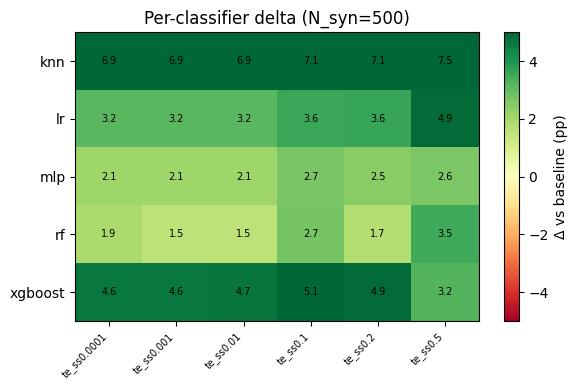

In [ ]:
if delta_cols:
    delta_mean = delta.groupby(['n_syn', 'classifier'])[delta_cols].mean()

    for n_syn in N_SYN_SWEEP:
        sub = delta_mean.loc[n_syn] if n_syn in delta_mean.index.get_level_values(0) else None
        if sub is None or sub.empty:
            continue
        fig, ax = plt.subplots(figsize=(max(6, len(delta_cols) * 0.8), 4))
        im = ax.imshow(sub.values, aspect='auto', cmap='RdYlGn', vmin=-5, vmax=5)
        ax.set_xticks(range(len(delta_cols)))
        ax.set_xticklabels([c.replace('Δ_vp_', '').replace('Δ_tabebm_', 'te_') for c in delta_cols],
                            rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(len(CLASSIFIERS)))
        ax.set_yticklabels(sub.index)
        for i in range(len(CLASSIFIERS)):
            for j in range(len(delta_cols)):
                v = sub.values[i, j]
                ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7)
        fig.colorbar(im, ax=ax, label='Δ vs baseline (pp)')
        ax.set_title(f'Per-classifier delta (N_syn={n_syn})')
        plt.tight_layout()
        fig.savefig(results_dir / f'delta_heatmap_n{n_syn}.png', dpi=120, bbox_inches='tight')
        plt.show()
else:
    print('  (aug_settings 없음 — config 선택 확인)')

## 12. N_SYN scaling curve

N_SYN 에 따른 성능 변화를 한 그래프로 시각화. config 별 × classifier 별.

In [ ]:
if len(N_SYN_SWEEP) > 1:
    for clf_name in CLASSIFIERS:
        fig, ax = plt.subplots(figsize=(8, 5))
        bl = df[df['classifier'] == clf_name]['baseline'].mean()
        ax.axhline(bl, color='gray', linestyle='--', linewidth=1, label='baseline')
        for sname in aug_settings:
            means, stds = [], []
            for n_syn in N_SYN_SWEEP:
                sub = df[(df['n_syn'] == n_syn) & (df['classifier'] == clf_name)]
                if sname in sub.columns:
                    means.append(sub[sname].mean())
                    stds.append(sub[sname].std())
                else:
                    means.append(np.nan); stds.append(0)
            means, stds = np.array(means), np.array(stds)
            short = sname.replace('vp_', '').replace('tabebm_', 'te_')
            ax.plot(N_SYN_SWEEP, means, 'o-', markersize=4, label=short)
            ax.fill_between(N_SYN_SWEEP, means - stds, means + stds, alpha=0.15)
        ax.set_xscale('log')
        ax.set_xlabel('N_SYN per class')
        ax.set_ylabel('balanced accuracy (%)')
        ax.set_title(f'{clf_name} — N_SYN scaling')
        ax.legend(fontsize=7, ncol=3, loc='best')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        fig.savefig(results_dir / f'nsyn_scaling_{clf_name}.png', dpi=150, bbox_inches='tight')
        plt.show()

    # all classifiers mean
    fig, ax = plt.subplots(figsize=(8, 5))
    bl = df['baseline'].mean()
    ax.axhline(bl, color='gray', linestyle='--', linewidth=1, label='baseline')
    for sname in aug_settings:
        means = [df[df['n_syn'] == n][sname].mean() if sname in df.columns else np.nan
                 for n in N_SYN_SWEEP]
        short = sname.replace('vp_', '').replace('tabebm_', 'te_')
        ax.plot(N_SYN_SWEEP, means, 'o-', markersize=4, label=short)
    ax.set_xscale('log')
    ax.set_xlabel('N_SYN per class')
    ax.set_ylabel('balanced accuracy (%) — all classifiers avg')
    ax.set_title('N_SYN scaling (mean over all classifiers)')
    ax.legend(fontsize=7, ncol=3, loc='best')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(results_dir / 'nsyn_scaling_all.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('N_SYN_SWEEP 단일 값 — scaling curve 생략')

N_SYN_SWEEP 단일 값 — scaling curve 생략
